# Pratica Guiada: EDA Completa com Dados Reais
### Unidade 1: Ciclo de Vida de ML e Feature Engineering
**Disciplina:** Machine Learning, Pos-Graduacao em IA Generativa e Aplicacoes com LLMs, PUC Minas
**Professor:** Mauricio Rodrigues da Silva

---

## Sobre este notebook

Este notebook e o roteiro que o professor usa **ao vivo, em sala**, para demonstrar todo o processo
de Analise Exploratoria de Dados (EDA) do inicio ao fim, usando um conjunto de dados real: o
**Medical Cost Personal Dataset** (custos de plano de saude nos EUA, `custo_medico.csv`).

Depois desta demonstracao, cada aluno fara a `tarefa_1_eda.ipynb` individualmente, aplicando o mesmo
processo sozinho, no mesmo dataset.

**Por que este dataset?** Ele tem variaveis numericas (`age`, `bmi`, `children`) e categoricas
(`sex`, `smoker`, `region`), um alvo continuo (`charges`, o custo do plano de saude), casos reais de
assimetria e outliers, e um padrao escondido de correlacao que so aparece quando segmentamos os
dados, o que torna a aula bem didatica. Alem disso, este mesmo dataset sera usado na Aula 2, de
Regressao: vamos prever `charges` a partir das demais variaveis.

**Roteiro da aula:**
1. Entendimento do problema de negocio
2. Carregamento e primeira inspecao (linhas, colunas, tipos, duplicatas)
3. Analise de distribuicoes (histograma, media e mediana)
4. Deteccao de outliers com IQR
5. Correlacao: o que o heatmap mostra e o que ele esconde
6. Analise categorica: o efeito do fumante no custo
7. Feature Engineering guiado por IA Generativa
8. Tratamento de dados ausentes e duplicatas
9. Codificacao de variaveis categoricas e escalonamento
10. Separacao treino/teste
11. Modelo baseline de regressao: ponte para a Aula 2

## 0. Preparando o ambiente

Como sempre, comecamos importando as bibliotecas centrais: **Pandas** e **NumPy** para manipulacao,
**Matplotlib** e **Seaborn** para visualizacao, e **Scikit-Learn** para pre-processamento e modelagem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Paleta usada nos graficos, alinhada com os slides da disciplina
NAVY = "#244357"
TEAL = "#23A8C3"
GOLD = "#F2A53D"
ALERT = "#C0504D"
SUCCESS = "#2E8B57"

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)

print("Ambiente pronto.")

Ambiente pronto.


## 1. Business Understanding: Custo de Plano de Saude

Antes de escrever qualquer linha de codigo, e preciso entender o problema de negocio:

- **Problema:** quais fatores explicam o custo (`charges`) do plano de saude de uma pessoa?
- **Objetivo (Aula 2):** construir um modelo de regressao capaz de prever `charges` a partir de
  idade, IMC, numero de filhos, sexo, habito de fumar e regiao.
- **Aplicacao pratica:** precificacao de planos, deteccao de perfis de alto custo, simulacao de
  impacto de habitos (por exemplo, parar de fumar) no valor pago.

Toda etapa desta EDA serve a uma pergunta central: **o que explica um `charges` alto?** Vamos deixar
os dados responderem.

## 2. Carregando os dados

O `custo_medico.csv` e o classico **Medical Cost Personal Dataset**, com 1338 registros e 7 colunas:

| Coluna | Tipo | Descricao |
|---|---|---|
| `age` | numerica | idade do beneficiario |
| `sex` | categorica | sexo biologico (male / female) |
| `bmi` | numerica | indice de massa corporal |
| `children` | numerica | numero de filhos/dependentes cobertos pelo plano |
| `smoker` | categorica | se a pessoa fuma (yes / no) |
| `region` | categorica | regiao residencial nos EUA |
| `charges` | numerica (alvo) | custo do plano de saude, em dolares |

Diferente da pratica anterior, aqui **nao vamos gerar dados sinteticos**: o arquivo e um dataset real,
carregado diretamente com `pd.read_csv`.

In [3]:
df = pd.read_csv('../Assignments/01-EDA-feature-engineering/dataset/custo_medico.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


## 3. Primeira Inspecao

Antes de qualquer grafico, respondemos as perguntas basicas: quantas linhas e colunas temos? Quais os
tipos de cada variavel? Existem valores ausentes? Existem linhas duplicadas?

In [7]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.describe().T

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


**Leitura rapida do `describe`:** a idade (`age`) vai de 18 a 64 anos, com media proxima de 39. O
IMC (`bmi`) tem media perto de 30,7, ja na faixa de sobrepeso segundo a OMS. O `charges` tem media de
cerca de 13.270 dolares, mas mediana bem menor, de 9.382 dolares, o que ja e um primeiro sinal de
assimetria a direita: poucos valores muito altos puxam a media para cima.

In [18]:
print("Valores ausentes por coluna:")
print(df.isna().sum())

print("\nLinhas duplicadas:", df.duplicated().sum())

Valores ausentes por coluna:

Linhas duplicadas: 0


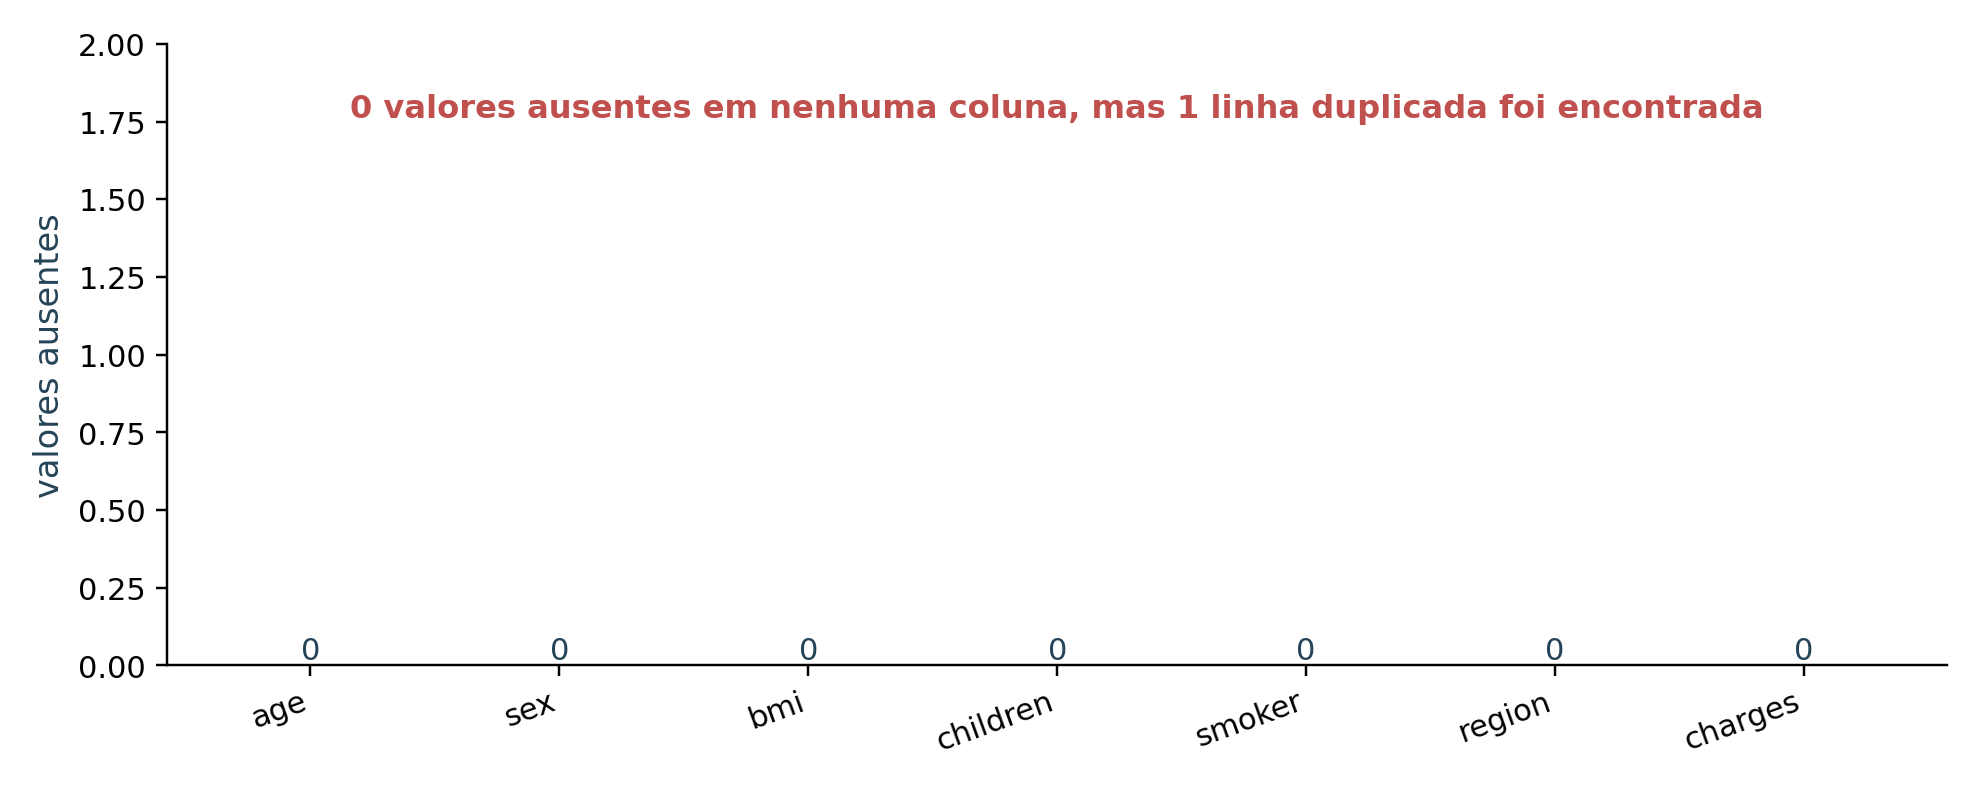

*Nenhuma coluna tem valor ausente, mas o exame de duplicatas encontrou 1 linha repetida no dataset. Ausencia de nulos nao significa que os dados estao 100% limpos.*

**Ponto de atencao pedagogico:** este dataset real nao tem nenhum valor ausente (`isna().sum()` =
0 em todas as colunas), mas tem **1 linha duplicada**. Isso e importante: um dataset "limpo" quanto a
nulos ainda pode ter outros problemas de qualidade, como registros repetidos. Vamos tratar essa
duplicata na Secao 8.

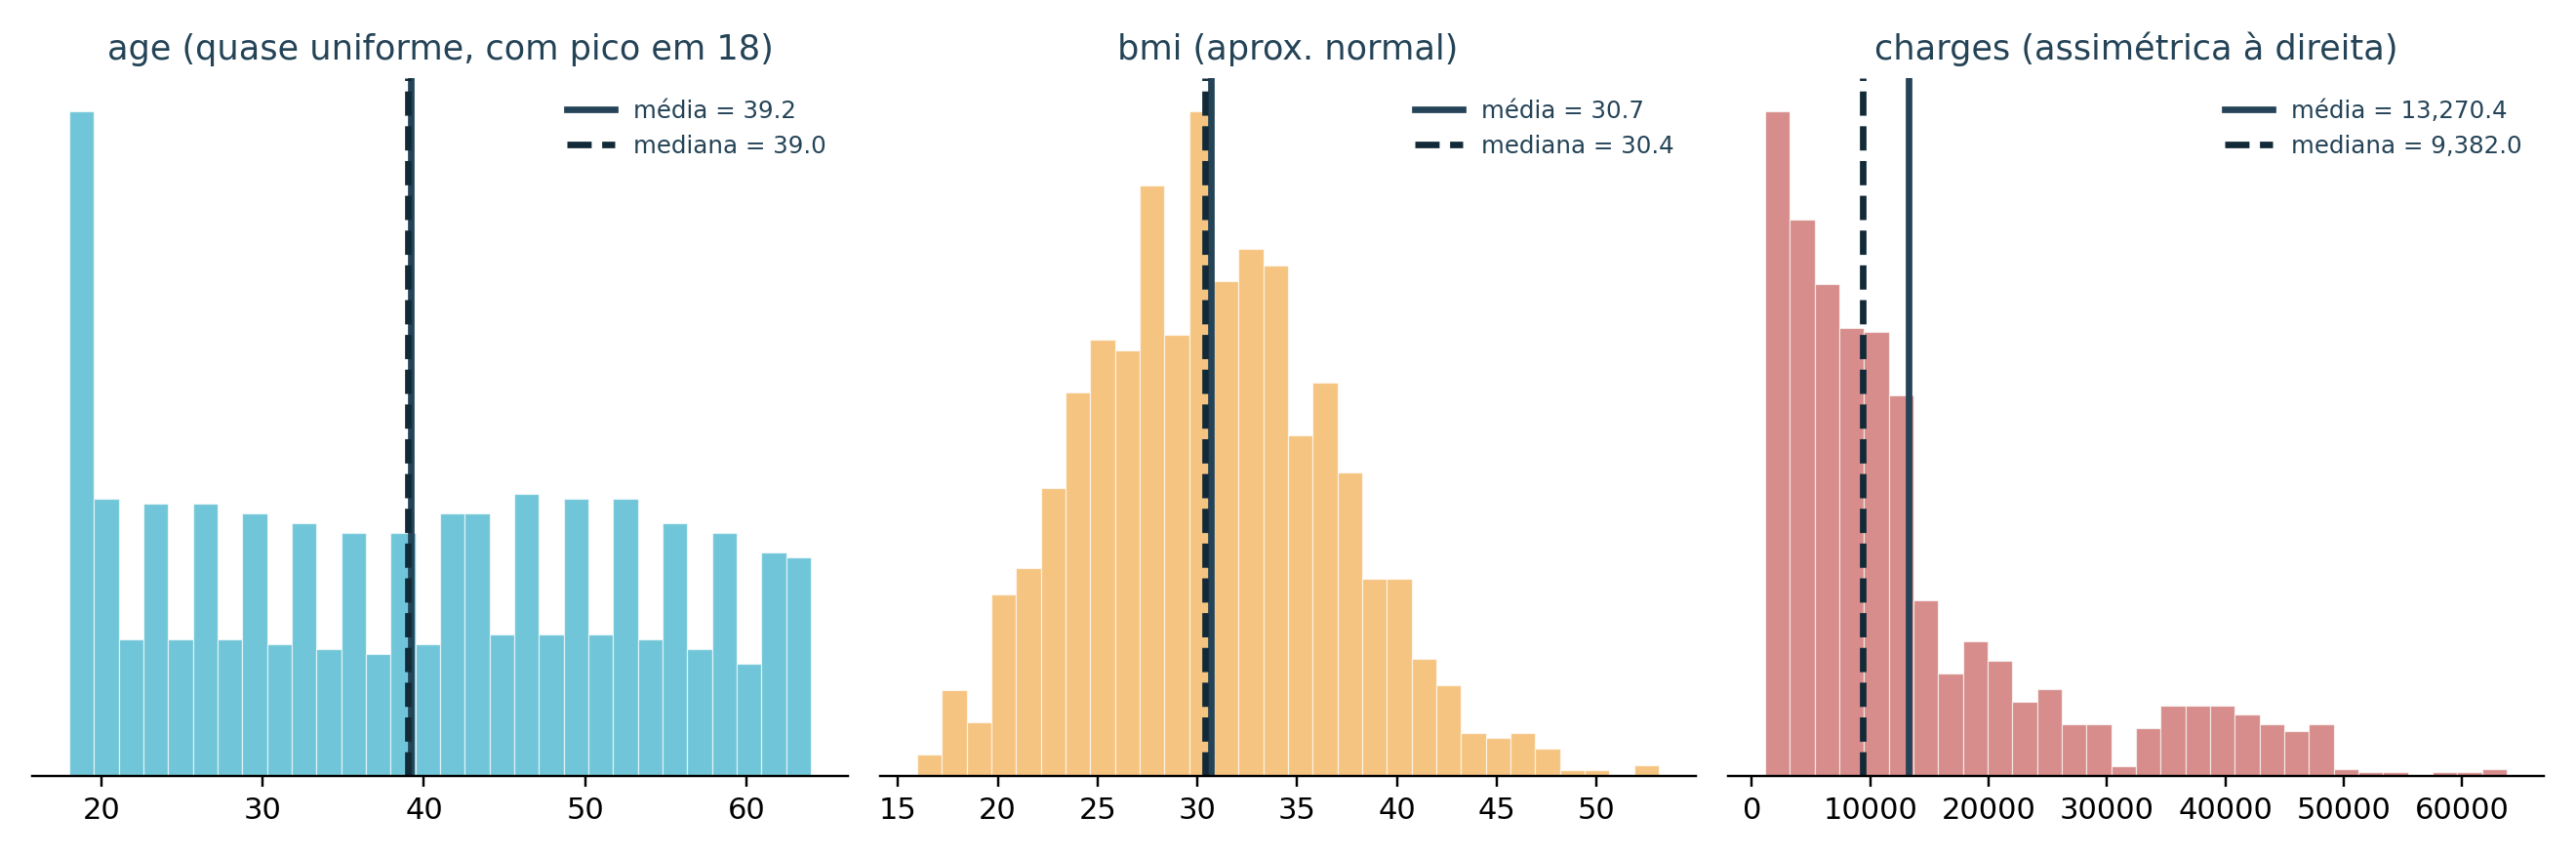

*age e quase uniforme, com um pico em 18 anos. bmi se aproxima de uma distribuicao normal. charges e claramente assimetrica a direita, com uma cauda longa de valores altos.*

## 4. Analise de Distribuicoes

**Perguntas que a EDA de distribuicao responde:**
- Os dados sao simetricos ou assimetricos?
- Ha multiplos picos (multimodal)?
- A relacao entre media e mediana ja denuncia a assimetria?
- Precisamos de transformacao (log, Box-Cox) antes de modelar?

A imagem acima mostra os tres perfis presentes no nosso dataset: `age` quase uniforme (com um pico em
18 anos, idade minima de adesao ao plano), `bmi` proximo de uma normal, e `charges` fortemente
assimetrico a direita. Vamos confirmar isso com o proprio dataset, olhando `charges` em detalhe.

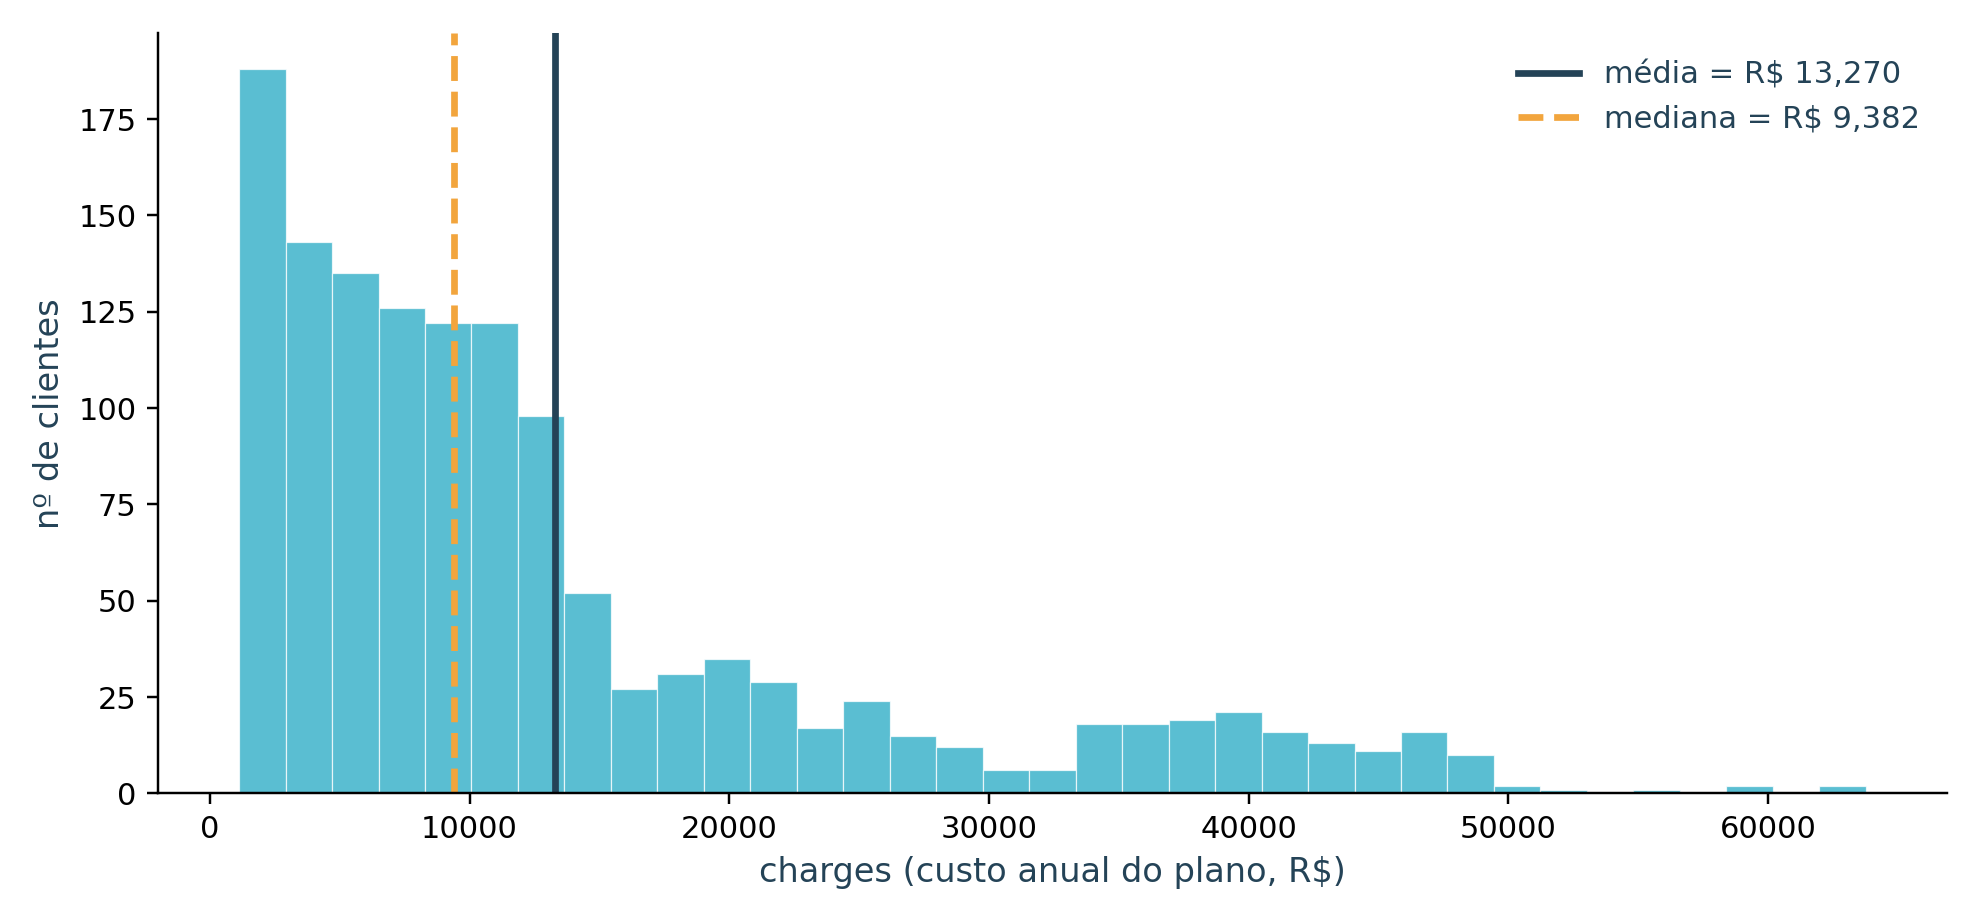

*Histograma de charges com as linhas de media e mediana marcadas. A media fica acima da mediana, confirmando a assimetria a direita.*

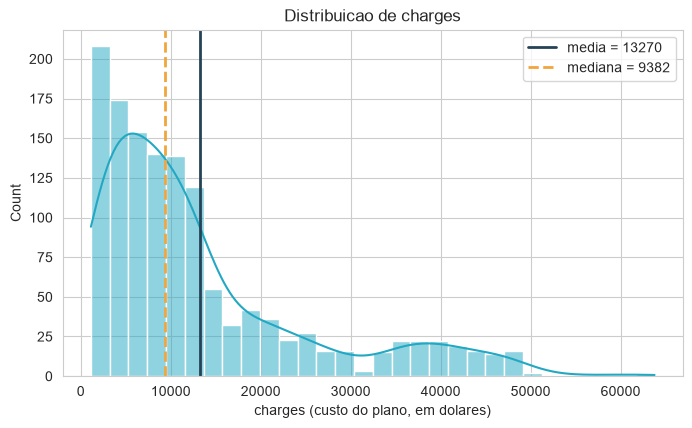

media = 13270.42 | mediana = 9382.03
Media > mediana -> True (esperado para assimetria a direita)


In [19]:
media = df["charges"].mean()
mediana = df["charges"].median()

plt.figure(figsize=(8, 4.5))
sns.histplot(df["charges"], kde=True, color=TEAL)
plt.axvline(media, color=NAVY, linewidth=2, label=f"media = {media:.0f}")
plt.axvline(mediana, color=GOLD, linewidth=2, linestyle="--", label=f"mediana = {mediana:.0f}")
plt.xlabel("charges (custo do plano, em dolares)")
plt.legend()
plt.title("Distribuicao de charges")
plt.show()

print(f"media = {media:.2f} | mediana = {mediana:.2f}")
print("Media > mediana ->", media > mediana, "(esperado para assimetria a direita)")

**Ponto para discutir em sala:** por que `charges` e tao assimetrico? A resposta aparece nas
proximas secoes: existe um grupo pequeno (os fumantes) com custos muito mais altos que o resto da
populacao, e isso puxa a cauda direita da distribuicao.

## 5. Deteccao de Outliers com IQR

**IQR (Intervalo Interquartil) = Q3 - Q1.** Um ponto e considerado outlier se estiver fora do
intervalo:

$$[\,Q1 - 1{,}5 \times IQR \;,\; Q3 + 1{,}5 \times IQR\,]$$

Importante: a decisao de remover ou manter um outlier e **sempre uma decisao de negocio**, nunca
automatica. Aqui, vamos aplicar o metodo a `charges` e discutir o que os outliers realmente
significam.

In [25]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["charges"] < limite_inferior) | (df["charges"] > limite_superior)]
print(f"Limite inferior: {limite_inferior:.2f} | Limite superior: {limite_superior:.2f}")
print(f"{len(outliers)} outliers encontrados em charges, de um total de {len(df)} linhas")
print("\nProporcao de fumantes entre os outliers:", (outliers["smoker"] == "yes").mean().round(3))
print("Proporcao de fumantes no dataset todo:  ", (df["smoker"] == "yes").mean().round(3))

Limite inferior: -13109.15 | Limite superior: 34489.35
139 outliers encontrados em charges, de um total de 1338 linhas

Proporcao de fumantes entre os outliers: 0.978
Proporcao de fumantes no dataset todo:   0.205


**A pergunta certa muda tudo:** repare que a proporcao de fumantes entre os outliers e muito maior
do que no dataset como um todo. Ou seja, o que parecia "ruido estatistico" e, na verdade, um sinal de
negocio real: fumar esta fortemente associado a custos extremos de plano de saude. Remover esses
outliers as cegas apagaria justamente a informacao mais importante do dataset.

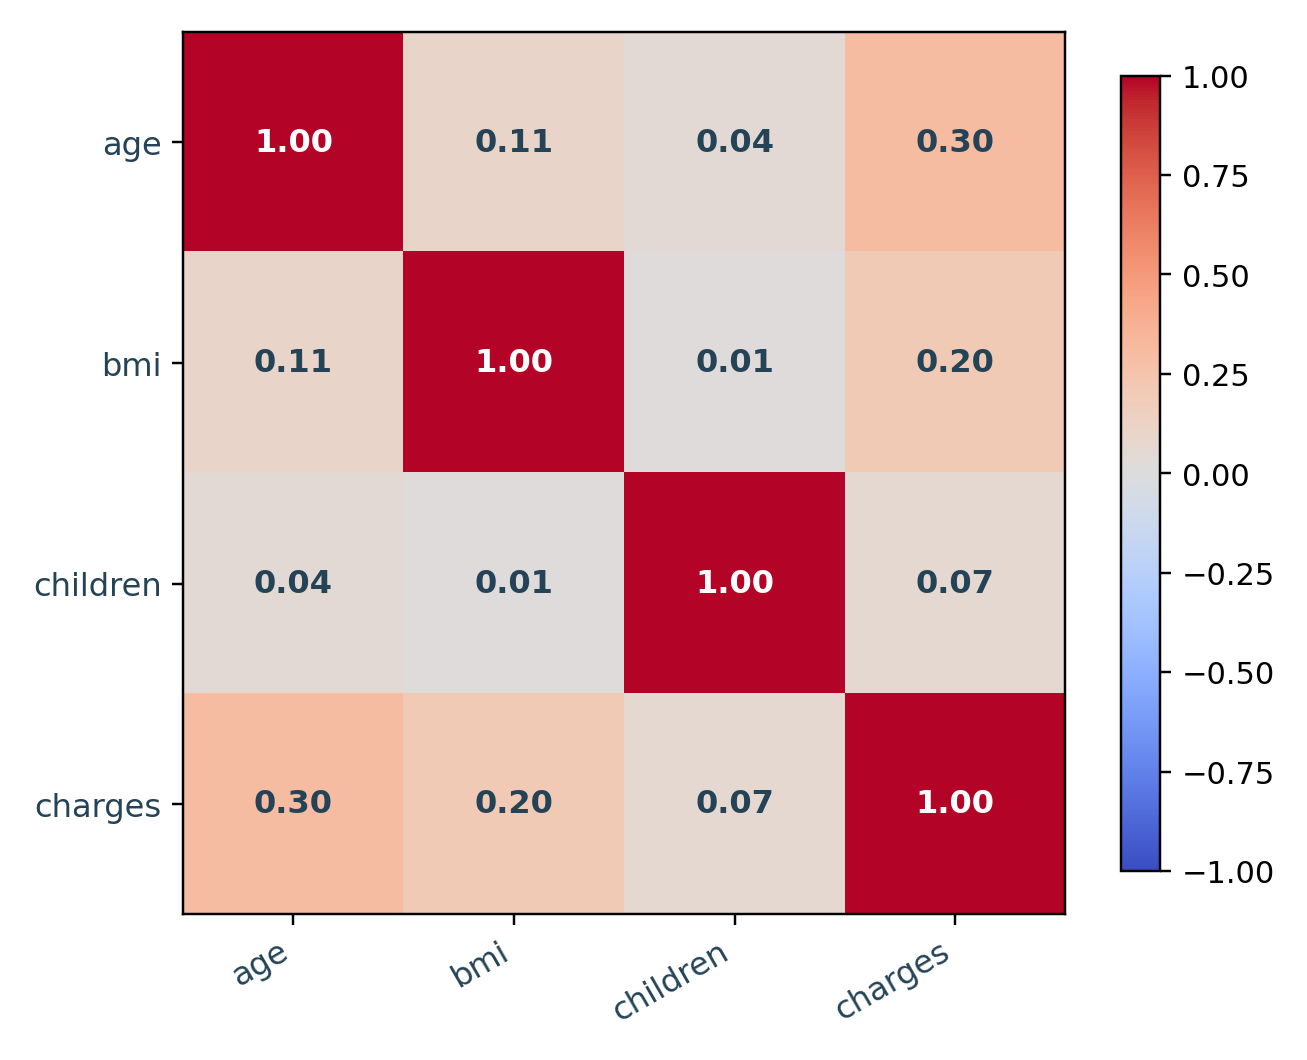

*Matriz de correlacao entre age, bmi, children e charges. Todas as correlacoes numericas diretas sao fracas a moderadas.*

## 6. Correlacao entre Variaveis

O heatmap e o "resumo executivo" de todas as correlacoes numericas do dataset de uma vez.

| Faixa de r (Pearson) | Interpretacao |
|---|---|
| 0,00 a 0,19 | Muito fraca ou nula |
| 0,20 a 0,39 | Fraca |
| 0,40 a 0,59 | Moderada |
| 0,60 a 0,79 | Forte |
| 0,80 a 1,00 | Muito forte |

Vamos calcular a matriz de correlacao real do nosso dataset.

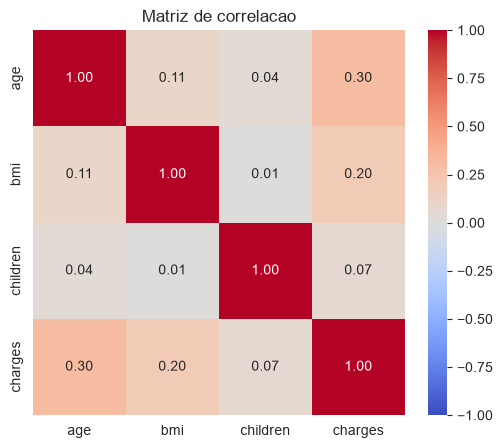

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [21]:
numericas = df[["age", "bmi", "children", "charges"]]
corr = numericas.corr()  # Pearson por padrao

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlacao")
plt.show()

corr

**Reparem:** `age` tem a maior correlacao com `charges`, mas ainda assim e considerada fraca
(perto de 0,30). Isso e surpreendente, porque intuitivamente esperariamos que idade tivesse mais peso
no custo de saude. O heatmap, sozinho, **esconde** a explicacao. Vamos revelar o que esta por tras
disso na proxima secao, com um grafico de dispersao segmentado.

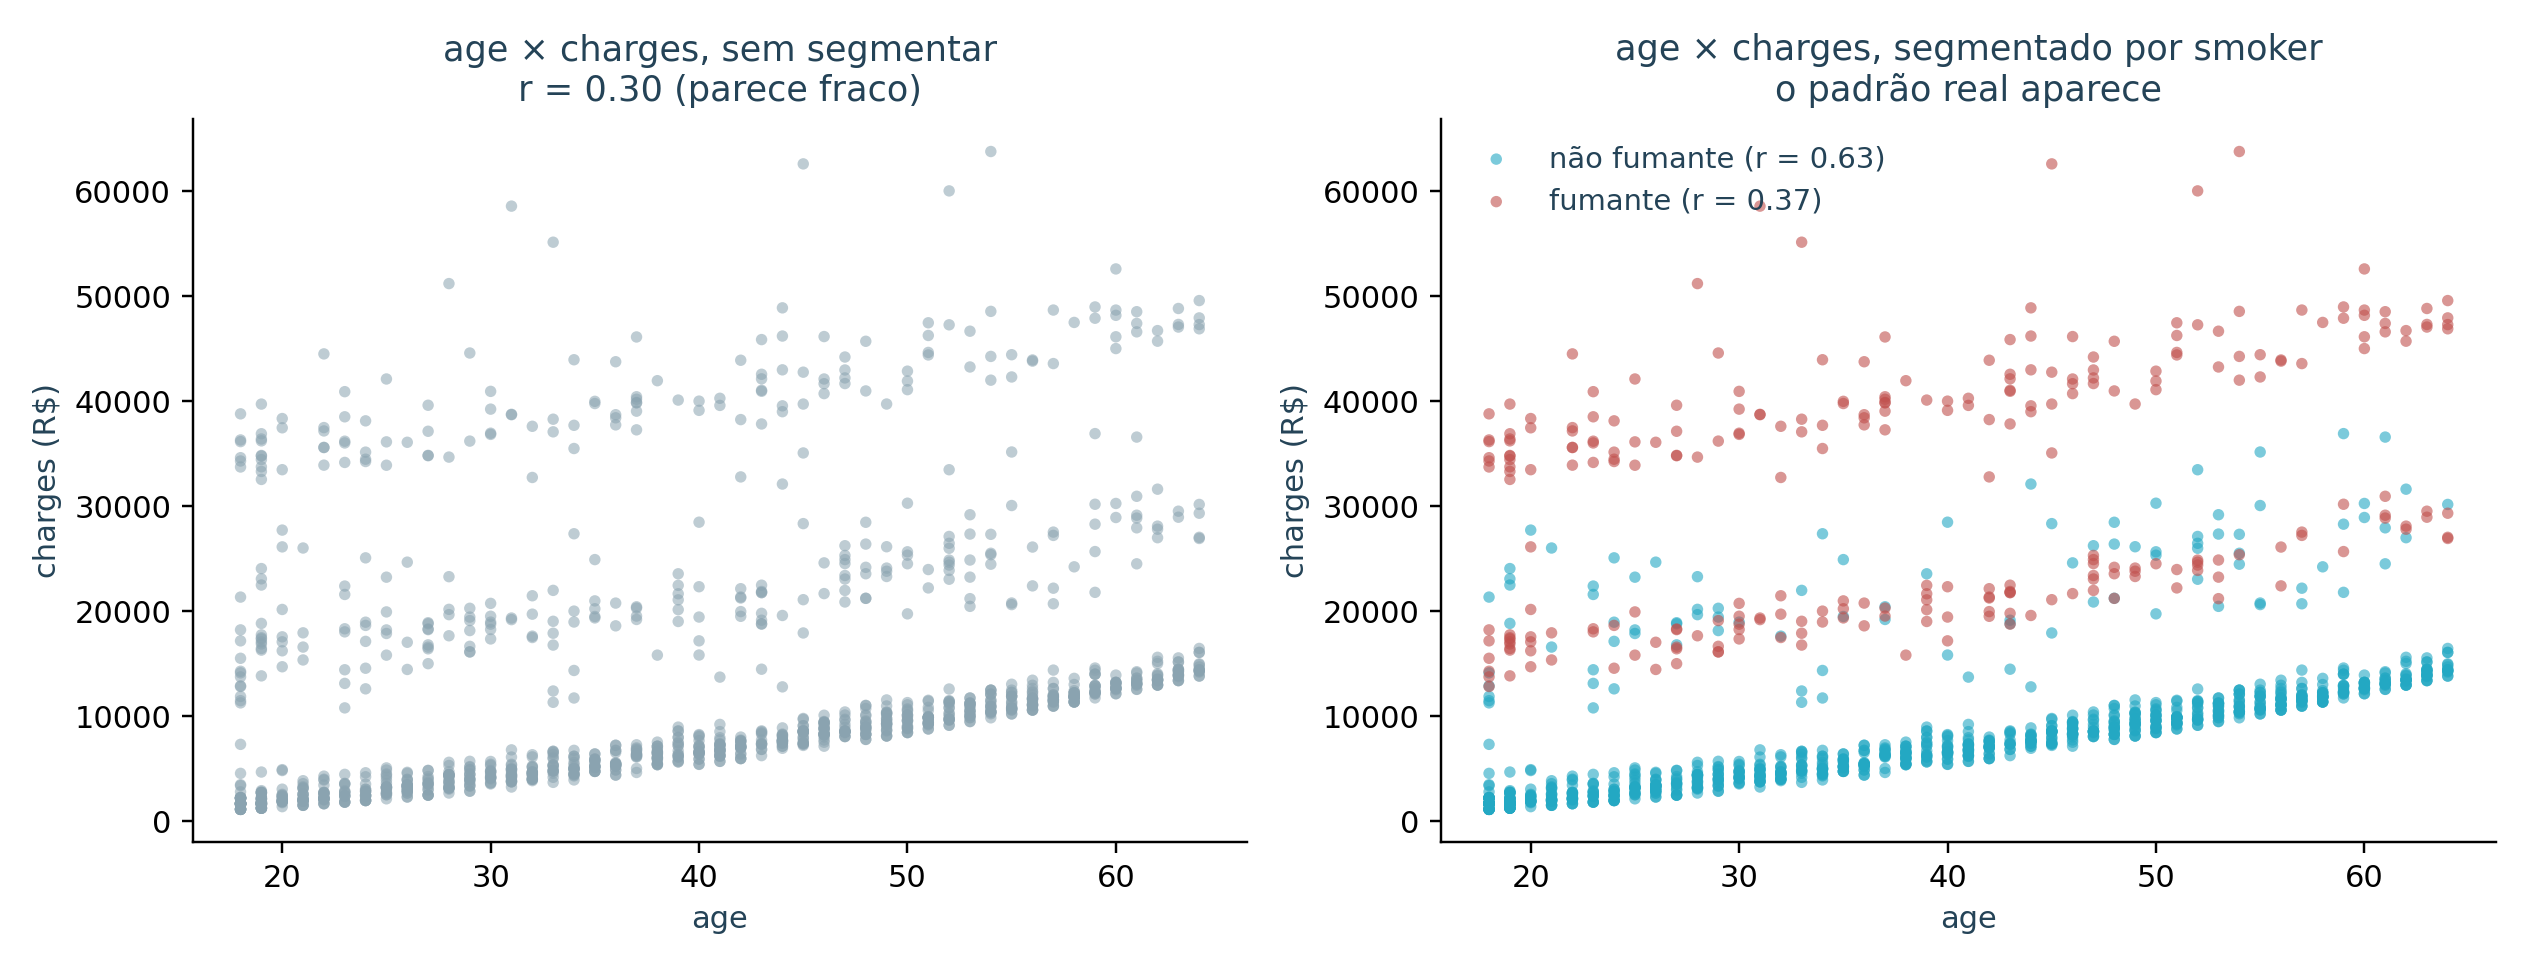

*Sem segmentar (esquerda), a correlacao entre age e charges parece fraca (r perto de 0,30). Segmentando por smoker (direita), duas relacoes fortes aparecem: entre nao fumantes o r sobe para perto de 0,63, e entre fumantes para perto de 0,37, com dois grupos de custo bem distintos.*

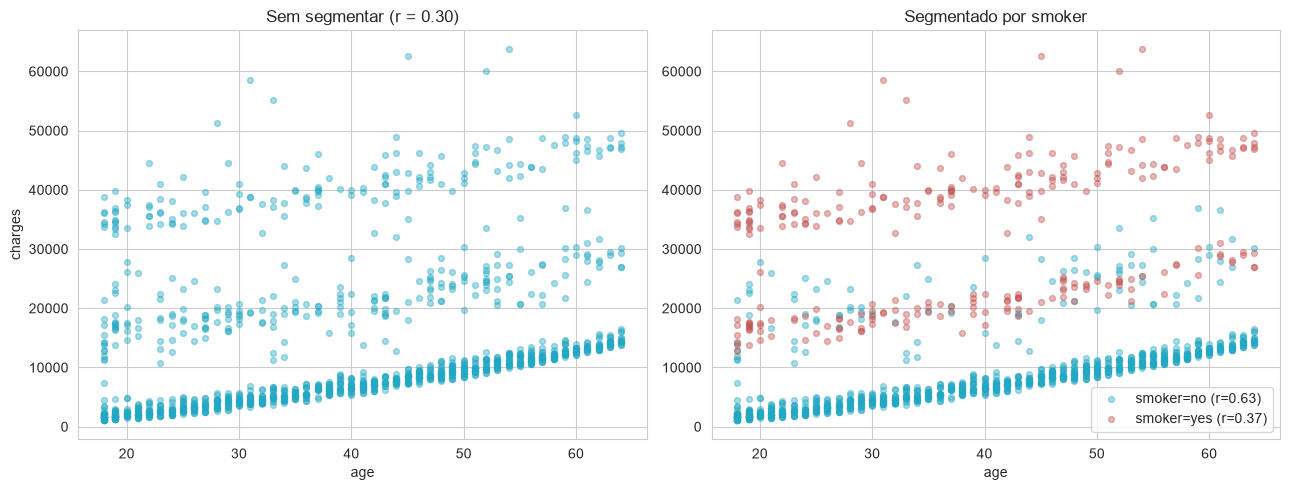

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sem segmentacao
axes[0].scatter(df["age"], df["charges"], alpha=0.4, color=TEAL, s=18)
r_geral = df["age"].corr(df["charges"])
axes[0].set_title(f"Sem segmentar (r = {r_geral:.2f})")
axes[0].set_xlabel("age")
axes[0].set_ylabel("charges")

# Segmentado por smoker
cores = {"no": TEAL, "yes": ALERT}
for grupo, cor in cores.items():
    subset = df[df["smoker"] == grupo]
    r_grupo = subset["age"].corr(subset["charges"])
    axes[1].scatter(subset["age"], subset["charges"], alpha=0.4, color=cor, s=18,
                     label=f"smoker={grupo} (r={r_grupo:.2f})")
axes[1].set_title("Segmentado por smoker")
axes[1].set_xlabel("age")
axes[1].legend()

plt.tight_layout()
plt.show()

**Licao central da aula:** um heatmap de correlacao mostra apenas relacoes lineares globais. Quando
existe uma variavel categorica que separa a populacao em subgrupos com comportamentos diferentes (aqui,
`smoker`), a correlacao "escondida" dentro de cada subgrupo pode ser bem mais forte do que a correlacao
geral sugere. Sempre que uma correlacao vier fraca, vale perguntar: **existe uma variavel categorica
relevante que eu ainda nao usei para segmentar?**

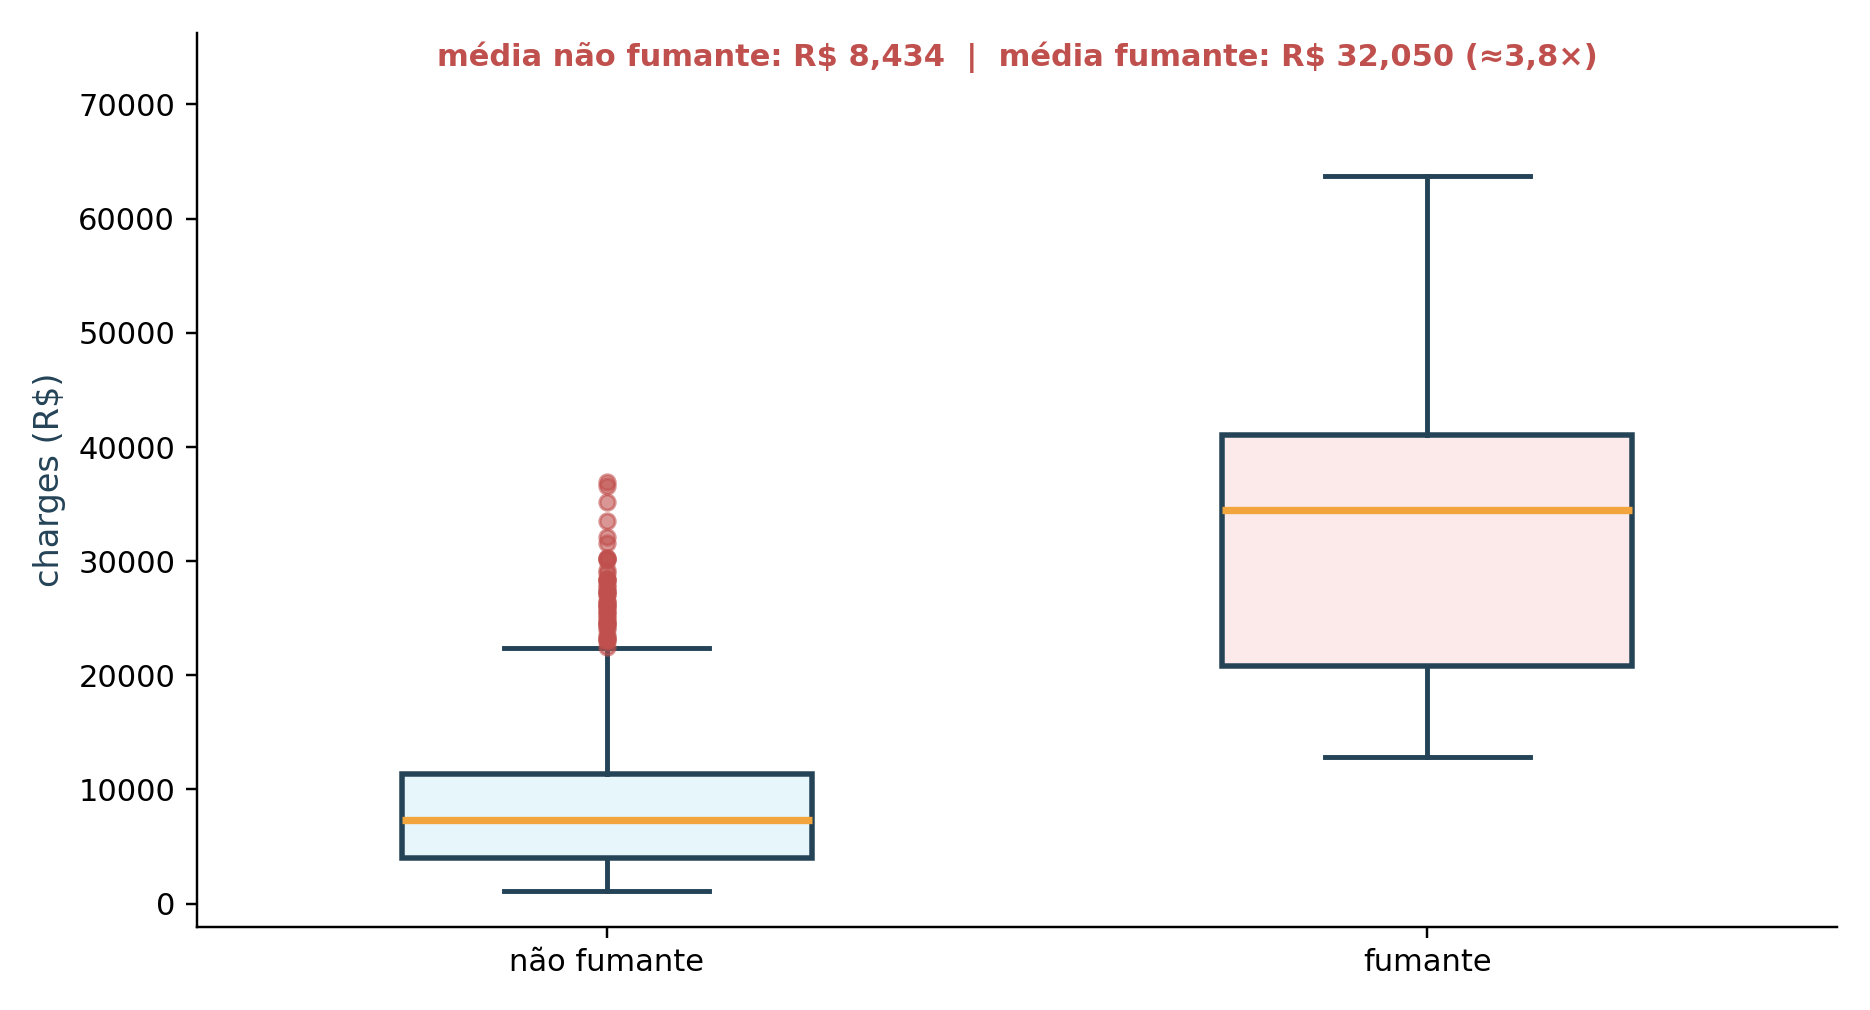

*Fumantes tem custo mediano muito mais alto que nao fumantes, com quase nenhuma sobreposicao entre os dois grupos.*

## 7. Analise Categorica: o Efeito do Fumante

Vamos confirmar numericamente o que o grafico de dispersao ja sugeriu: comparar `charges` entre
fumantes e nao fumantes com um boxplot e com as estatisticas de cada grupo.

            mean    median       std  count
smoker                                     
no       8434.27   7345.41   5993.78   1064
yes     32050.23  34456.35  11541.55    274


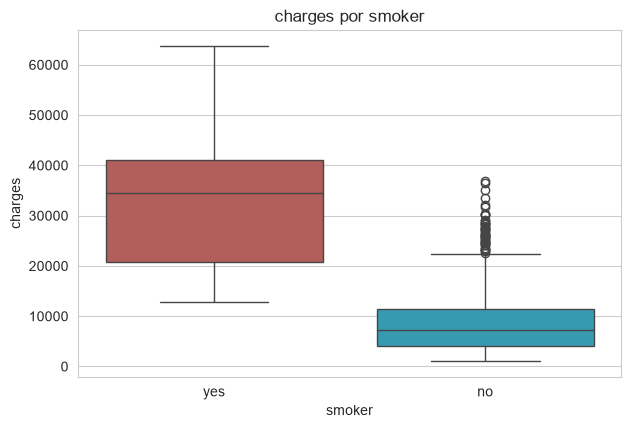


Um fumante gasta, em media, 3.8x mais que um nao fumante.


In [24]:
resumo_smoker = df.groupby("smoker")["charges"].agg(["mean", "median", "std", "count"]).round(2)
print(resumo_smoker)

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker",
            palette={"no": TEAL, "yes": ALERT}, legend=False)
plt.title("charges por smoker")
plt.show()

razao = resumo_smoker.loc["yes", "mean"] / resumo_smoker.loc["no", "mean"]
print(f"\nUm fumante gasta, em media, {razao:.1f}x mais que um nao fumante.")

**Discussao em sala:** `smoker` e uma variavel categorica binaria, mas e o fator isolado mais forte
para explicar `charges` neste dataset, muito mais forte do que qualquer variavel numerica sozinha.
Isso ja antecipa uma decisao de Feature Engineering: talvez valha a pena criar uma feature que combine
`smoker` com `age` ou `bmi`, ja que o efeito de uma pode depender da outra.

## 8. Feature Engineering com IA Generativa

Com o diagnostico da EDA em maos (fumante importa muito, idade e bmi importam pouco sozinhos, mas
talvez importem combinados com o habito de fumar), vamos usar um LLM como copiloto de brainstorming.
A metodologia e o **PBL Aumentado**: a IA sugere, voce audita, voce implementa, nesta ordem, sempre.

### O prompt (use no ChatGPT, Claude ou Gemini de sua escolha)

```
Atue como um Cientista de Dados Senior especialista em SEGUROS DE SAUDE.
Dataset: age, sex, bmi, children, smoker, region, charges.
Objetivo: prever CHARGES (regressao).

A EDA mostrou que smoker isolado explica muito mais charges do que age ou bmi sozinhos, e que a
correlacao entre age e charges so fica forte quando segmentada por smoker.

Crie 4 NOVAS FEATURES que ajudem a prever charges, considerando essa interacao. Para cada uma,
explique: nome e formula, por que ajuda, codigo Pandas, e sinalize risco de DATA LEAKAGE.
```

### Checklist do Auditor de Features

Aplique este checklist a **cada** feature sugerida pela IA, nunca confie cegamente:

1. Os dados para calcular a feature **existem**? (Se nao, e alucinacao, descarte.)
2. A feature tem **sentido de negocio**? (Uma seguradora concordaria?)
3. Nao ha **data leakage**? (Nao usa informacao do futuro ou do conjunto de teste?)
4. E **computacionalmente viavel**?

Abaixo, implementamos 4 features de exemplo ja auditadas, todas inspiradas diretamente nos padroes que
a propria EDA revelou.

In [28]:
df_feat = df.copy()

# Feature 1: categoria de IMC segundo faixas clinicas da OMS
def categoria_bmi(bmi):
    if bmi < 18.5:
        return "abaixo_do_peso"
    elif bmi < 25:
        return "peso_normal"
    elif bmi < 30:
        return "sobrepeso"
    else:
        return "obesidade"

df_feat["bmi_category"] = df_feat["bmi"].apply(categoria_bmi)

# Feature 2: faixa etaria (grupos de 10 anos)
df_feat["age_group"] = pd.cut(
    df_feat["age"], bins=[17, 29, 39, 49, 59, 65],
    labels=["18_29", "30_39", "40_49", "50_59", "60_64"]
)

# Feature 3: interacao fumante x obesidade (o combo mais caro, segundo a EDA)
df_feat["smoker_and_obese"] = (
    (df_feat["smoker"] == "yes") & (df_feat["bmi"] >= 30)
).astype(int)

# Feature 4: interacao numerica fumante x idade (fumante=1/0 multiplicado pela idade)
df_feat["smoker_x_age"] = (df_feat["smoker"] == "yes").astype(int) * df_feat["age"]

df_feat[["age", "bmi", "smoker", "bmi_category", "age_group",
         "smoker_and_obese", "smoker_x_age"]].head()

,age,bmi,smoker,bmi_category,age_group,smoker_and_obese,smoker_x_age
0,19,27.900,yes,sobrepeso,18_29,0,19
1,18,33.770,no,obesidade,18_29,0,0
2,28,33.000,no,obesidade,18_29,0,0
3,33,22.705,no,peso_normal,30_39,0,0
4,32,28.880,no,sobrepeso,30_39,0,0


**Validacao rapida com o Checklist do Auditor:** `smoker_and_obese` passa nos 4 criterios, e usa
apenas colunas que ja existem, tem justificativa clinica e de negocio (o combo fumante + obesidade e
conhecido por elevar risco de saude), nao usa nenhuma informacao do futuro, e e uma simples operacao
booleana. Vamos conferir se o novo grupo realmente tem `charges` mais alto:

In [29]:
df_feat.groupby("smoker_and_obese")["charges"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
smoker_and_obese,,,
0,9832.29,8334.59,1193
1,41557.99,40904.20,145


O grupo `smoker_and_obese = 1` tem media de `charges` nitidamente mais alta que o restante, o que
confirma que a feature capturou um padrao real e util para a Aula 2 de regressao.

## 9. Pre-processamento

### 9.1 Duplicatas

Vimos na Secao 3 que existe 1 linha duplicada. Diferente de dados ausentes, uma duplicata exata nao
tem "causa a investigar": e o mesmo registro contado duas vezes, e deve ser removida antes de treinar
qualquer modelo, para nao dar peso artificial a esse ponto.

In [30]:
print("Linhas antes de remover duplicatas:", len(df_feat))
df_feat = df_feat.drop_duplicates().reset_index(drop=True)
print("Linhas depois de remover duplicatas:", len(df_feat))

Linhas antes de remover duplicatas: 1338
Linhas depois de remover duplicatas: 1337


### 9.2 Dados ausentes: simulando o cenario, mesmo sem nulos reais

O `custo_medico.csv` nao tem nenhum valor ausente de verdade, mas em qualquer projeto real isso pode
acontecer (falha de sistema, campo opcional nao preenchido). Para nao pular essa etapa essencial do
ciclo de vida de ML, vamos **simular** ausencia em copia do dataframe, so para fins didaticos, e
mostrar como o `SimpleImputer` e o `KNNImputer` funcionam na pratica.

In [32]:
# Copia so para demonstracao: nao afeta df_feat, que segue sem nulos artificiais
rng = np.random.default_rng(42)
df_demo_nulos = df_feat.copy()
idx_simulado = rng.choice(df_demo_nulos.index, size=40, replace=False)
df_demo_nulos.loc[idx_simulado, "bmi"] = np.nan

print("Nulos simulados em bmi:", df_demo_nulos["bmi"].isna().sum())

# Estrategia 1: imputacao simples pela mediana (robusta a outliers)
imputer_simples = SimpleImputer(strategy="median")
bmi_imputado_simples = imputer_simples.fit_transform(df_demo_nulos[["bmi"]])

# Estrategia 2: imputacao por KNN, usando idade e numero de filhos como referencia
imputer_knn = KNNImputer(n_neighbors=5)
bmi_imputado_knn = imputer_knn.fit_transform(
    df_demo_nulos[["age", "children", "bmi"]]
)[:, -1]

print("Media do bmi original:        ", df_feat['bmi'].mean().round(2))
print("Media apos imputacao (mediana):", bmi_imputado_simples.mean().round(2))
print("Media apos imputacao (KNN):     ", bmi_imputado_knn.mean().round(2))

Nulos simulados em bmi: 40
Media do bmi original:         30.66
Media apos imputacao (mediana): 30.6
Media apos imputacao (KNN):      30.64


Como o dataset real segue sem nulos (`df_feat`, usado do ponto em diante), continuamos o pipeline
sem precisar aplicar nenhuma imputacao real, mas o processo acima e exatamente o que voces usariam se
o dataset tivesse valores ausentes de fato.

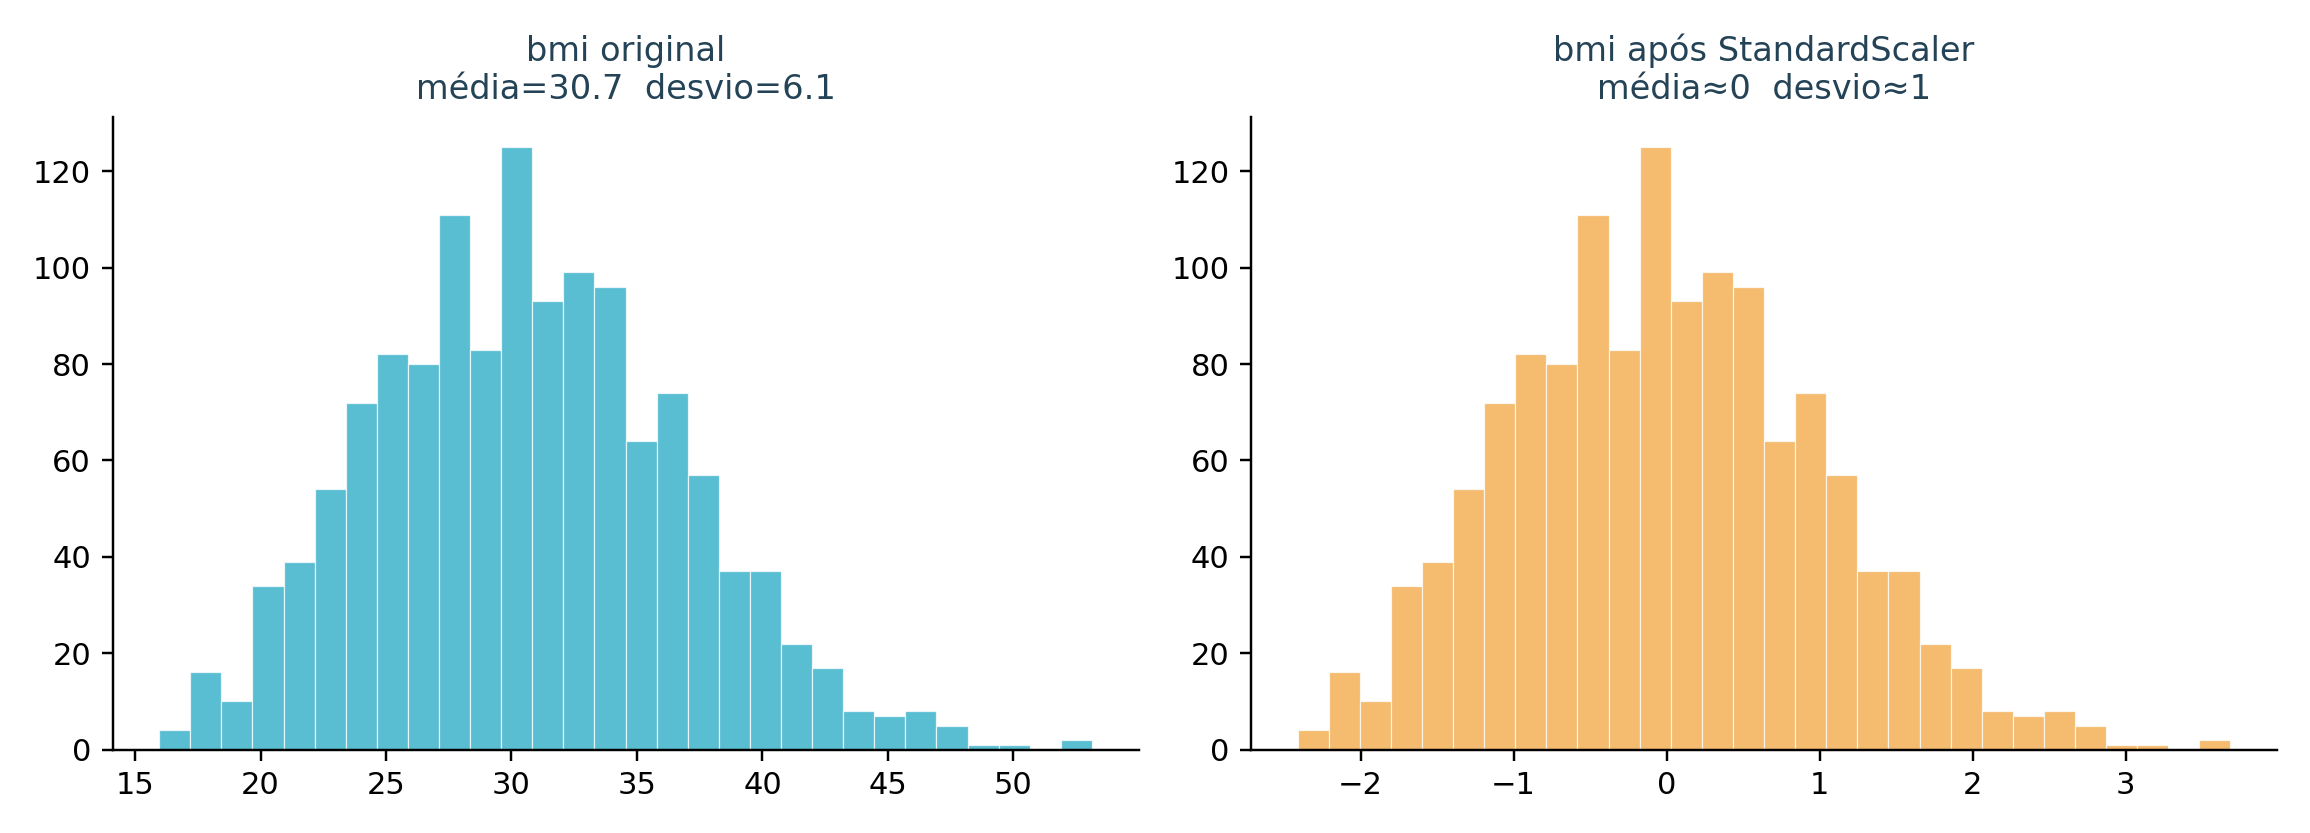

*Antes do StandardScaler, bmi tem media proxima de 30,7. Depois, media 0 e desvio padrao 1, mantendo o mesmo formato da distribuicao.*

### 9.3 Escalonamento

- **StandardScaler (padronizacao):** transforma para media 0 e desvio padrao 1, `z = (x - media) / desvio`.
  Ideal para regressao linear, SVM, PCA; mais robusto a outliers.
- **MinMaxScaler (normalizacao):** comprime para o intervalo [0, 1]. Ideal para redes neurais e k-NN;
  sensivel a outliers.

### 9.4 Codificacao categorica

| Tecnica | Quando usar | Cuidado |
|---|---|---|
| One-Hot Encoding | Categorias nominais (sex, smoker, region) | Aumenta dimensionalidade |
| Ordinal Encoding | Categorias com ranking natural (bmi_category, age_group) | Preserva a ordem |
| Target Encoding | Alta cardinalidade | Alto risco de data leakage se feito antes do split |

**Regra de ouro:** `fit()` apenas no **TREINO**; `transform()` no treino **e** no teste. Nunca use
`fit()` no dataset inteiro, e a forma mais comum de data leakage silencioso.

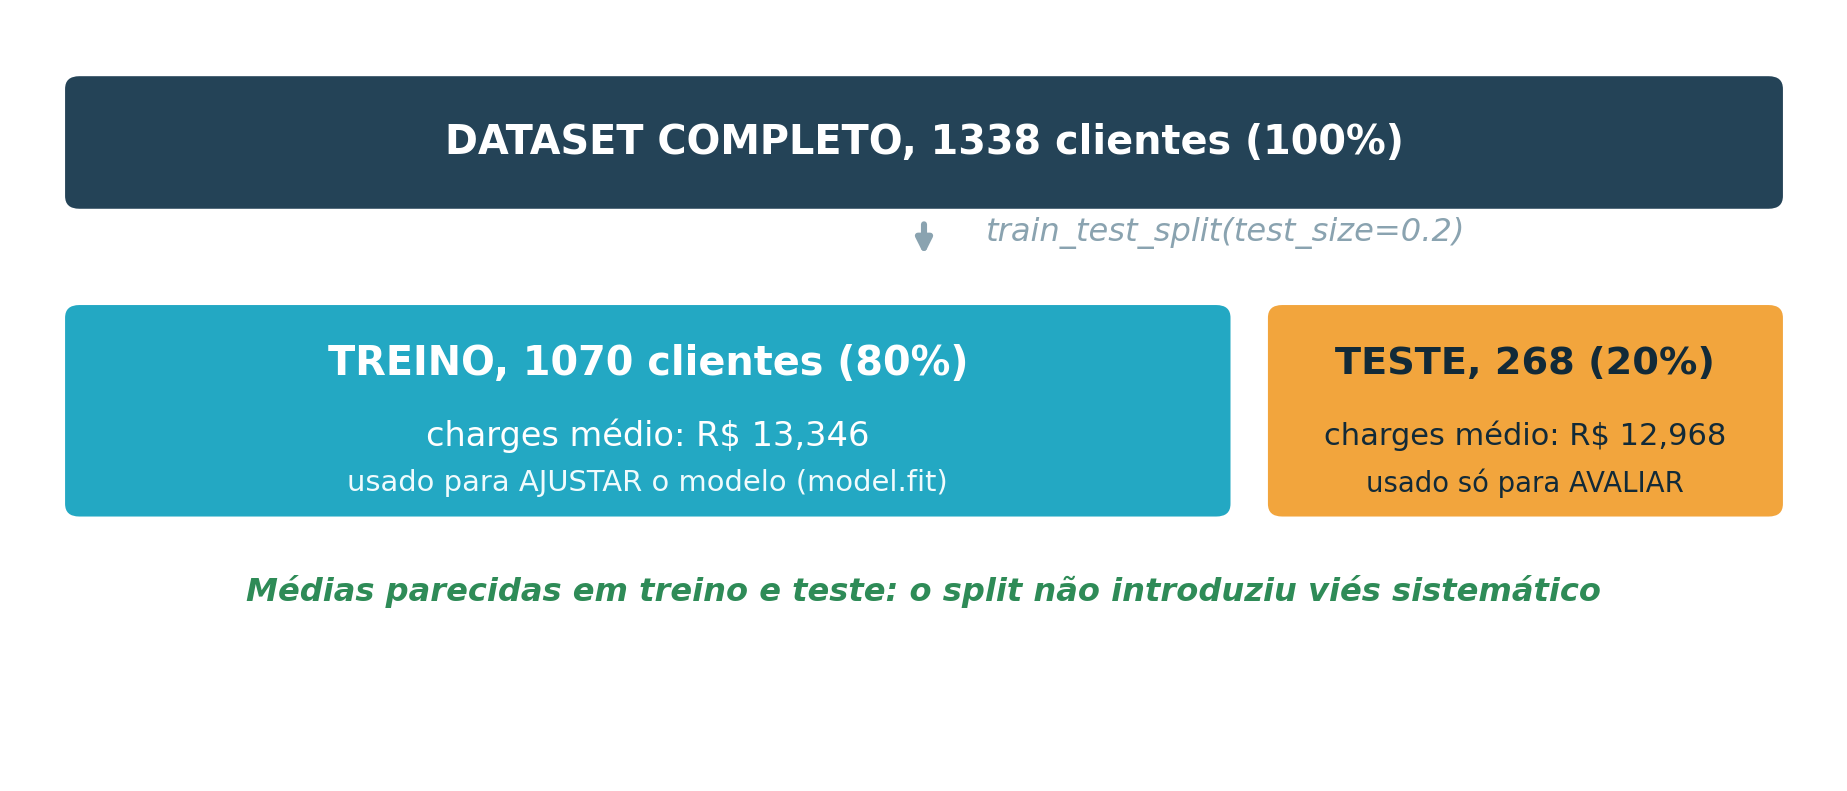

*1338 registros divididos em 80% treino (1070 linhas) e 20% teste (268 linhas), com media de charges semelhante nos dois conjuntos, sinal de uma divisao representativa.*

## 10. Separando Treino e Teste, Antes de Escalonar e Codificar

Esta e a **regra de ouro** da unidade: separar treino e teste **antes** de calcular qualquer
estatistica (media, desvio padrao, encoding) que dependa dos dados. Testar o modelo com os mesmos
dados do treino e como dar a prova com as respostas ao aluno.

In [35]:
features_numericas = ["age", "bmi", "children", "smoker_and_obese", "smoker_x_age"]
features_categoricas = ["sex", "smoker", "region", "bmi_category", "age_group"]

X = df_feat[features_numericas + features_categoricas].copy()
y = df_feat["charges"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Treino:", X_train.shape, "| media de charges:", y_train.mean().round(2))
print("Teste: ", X_test.shape, " | media de charges:", y_test.mean().round(2))

Treino: (1069, 10) | media de charges: 13030.2
Teste:  (268, 10)  | media de charges: 14272.01


In [34]:
X

,age,bmi,children,smoker_and_obese,smoker_x_age,sex,smoker,region,bmi_category,age_group
0,19,27.900,0,0,19,female,yes,southwest,sobrepeso,18_29
1,18,33.770,1,0,0,male,no,southeast,obesidade,18_29
2,28,33.000,3,0,0,male,no,southeast,obesidade,18_29
3,33,22.705,0,0,0,male,no,northwest,peso_normal,30_39
4,32,28.880,0,0,0,male,no,northwest,sobrepeso,30_39
...,...,...,...,...,...,...,...,...,...,...
1332,50,30.970,3,0,0,male,no,northwest,obesidade,50_59
1333,18,31.920,0,0,0,female,no,northeast,obesidade,18_29
1334,18,36.850,0,0,0,female,no,southeast,obesidade,18_29
1335,21,25.800,0,0,0,female,no,southwest,sobrepeso,18_29


In [29]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1332    10600.54830
1333     2205.98080
1334     1629.83350
1335     2007.94500
1336    29141.36030
Name: charges, Length: 1337, dtype: float64

In [27]:
# Agora sim: fit() SO no treino, transform() no treino e no teste

scaler = StandardScaler()
X_train[features_numericas] = scaler.fit_transform(X_train[features_numericas])
X_test[features_numericas] = scaler.transform(X_test[features_numericas])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_encoded = encoder.fit_transform(X_train[features_categoricas])
test_encoded = encoder.transform(X_test[features_categoricas])

encoded_cols = encoder.get_feature_names_out(features_categoricas)
X_train_final = pd.concat([
    X_train[features_numericas].reset_index(drop=True),
    pd.DataFrame(train_encoded, columns=encoded_cols)
], axis=1)
X_test_final = pd.concat([
    X_test[features_numericas].reset_index(drop=True),
    pd.DataFrame(test_encoded, columns=encoded_cols)
], axis=1)

X_train_final.head()

,age,bmi,children,smoker_and_obese,smoker_x_age,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_abaixo_do_peso,bmi_category_obesidade,bmi_category_peso_normal,bmi_category_sobrepeso,age_group_18_29,age_group_30_39,age_group_40_49,age_group_50_59,age_group_60_64
0,-1.157680,-0.996928,-0.907908,-0.333507,-0.462805,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.300619,-0.792762,0.766904,-0.333507,-0.462805,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,0.914926,1.154664,0.766904,-0.333507,-0.462805,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.701087,1.806837,-0.907908,-0.333507,-0.462805,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.557580,-0.651417,0.766904,-0.333507,-0.462805,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## 11. Modelo Baseline de Regressao: Ponte para a Aula 2

Para fechar a demonstracao, vamos treinar uma Regressao Linear simples (o algoritmo sera aprofundado
na Aula 2) duas vezes: uma so com as variaveis originais, outra incluindo as features que criamos na
Secao 8. O objetivo aqui nao e otimizar o modelo, e **validar se o Feature Engineering valeu a pena**,
e deixar o terreno pronto para a proxima aula.

In [ ]:
# Modelo A: so com as variaveis originais (sem as features criadas na Secao 8)
originais = ["age", "bmi", "children"]
cols_originais = [c for c in X_train_final.columns
                   if c in originais or c.startswith(("sex_", "smoker_", "region_"))
                   and not c.startswith(("smoker_and_obese", "smoker_x_age"))]

modelo_a = LinearRegression()
modelo_a.fit(X_train_final[cols_originais], y_train)
pred_a = modelo_a.predict(X_test_final[cols_originais])

# Modelo B: com todas as features, incluindo as criadas na Secao 8
modelo_b = LinearRegression()
modelo_b.fit(X_train_final, y_train)
pred_b = modelo_b.predict(X_test_final)

print("Modelo A (variaveis originais)")
print(f"  R2: {r2_score(y_test, pred_a):.3f} | MAE: {mean_absolute_error(y_test, pred_a):.2f}")
print("Modelo B (com Feature Engineering)")
print(f"  R2: {r2_score(y_test, pred_b):.3f} | MAE: {mean_absolute_error(y_test, pred_b):.2f}")

**Leitura do resultado:** o R2 mede a proporcao da variacao de `charges` explicada pelo modelo (mais
perto de 1 e melhor); o MAE (erro absoluto medio) mostra, em dolares, o quanto o modelo costuma errar.
Se o Modelo B tiver R2 maior e MAE menor que o Modelo A, isso confirma que as features criadas a partir
do diagnostico da EDA, sobretudo a interacao com `smoker`, realmente ajudam o modelo a prever melhor.

Isso e exatamente o ponto de partida da **Aula 2 (Regressao)**: vamos explorar outros algoritmos de
regressao, comparar metricas com mais profundidade, e discutir como interpretar os coeficientes do
modelo.

## Checklist da pratica guiada

- [ ] Entendemos o problema de negocio: prever `charges` a partir das demais variaveis.
- [ ] Carregamos o dataset real e fizemos a primeira inspecao (shape, tipos, nulos, duplicatas).
- [ ] Analisamos distribuicoes de `age`, `bmi` e `charges`, com media e mediana.
- [ ] Detectamos outliers em `charges` com IQR e interpretamos o que eles significam.
- [ ] Lemos o heatmap de correlacao e revelamos o padrao escondido com o scatter segmentado por `smoker`.
- [ ] Comparamos `charges` entre fumantes e nao fumantes com boxplot.
- [ ] Criamos features com apoio de IA Generativa, aplicando o Checklist do Auditor.
- [ ] Removemos a linha duplicada e demonstramos imputacao de dados ausentes (em copia simulada).
- [ ] Codificamos variaveis categoricas e escalonamos variaveis numericas, sempre depois do split.
- [ ] Comparamos um modelo baseline de regressao com e sem Feature Engineering.

**Proximo passo:** cada aluno repete este processo, sozinho, na `tarefa_1_eda.ipynb`, usando o mesmo
dataset `custo_medico.csv`.